In [1]:
import os
os.chdir(os.path.abspath(".."))

import warnings
warnings.filterwarnings("ignore")

## Setup
First of all, check the Python version. This sources have been coded with the following Python version:

In [2]:
!python --version

Python 3.11.2


Then, install the dependencies in the `requirement.txt` file. The main dependency is the python packege `bcause` (https://github.com/PGM-Lab/bcause).

In [ ]:
!pip install --upgrade pip setuptools wheel
!pip install -r ./requirements.txt

## Model and data

In this repository, we provide functionality for preprocessing the model and data so they could work we our inference algorithm:

In [3]:
from ctfzeros.prepro import load_and_preprocess

In [4]:
filepath = "./models/synthetic/simple_nparents2_nzr10_zdr05_13.uai"
datapath = "./models/synthetic/simple_nparents2_nzr10_zdr05_13.csv"

model, data, _, _ = load_and_preprocess(filepath, datapath)
model

<StructuralCausalModel (Y:2,X2:2,X1:2|Uy:16,Ux1:2,Ux2:2), dag=[Uy][Y|Uy:X2:X1][X2|Ux2][X1|Ux1][Ux1][Ux2]>

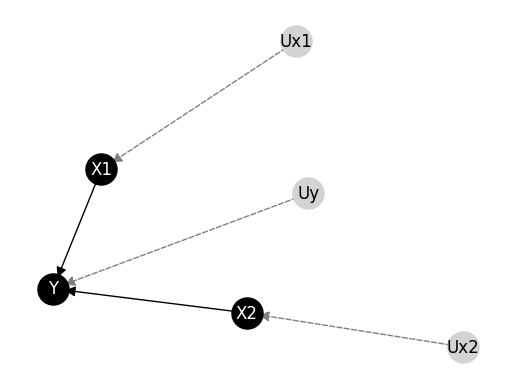

In [5]:
model.draw()

In [6]:
data

,X2,X1,Y
0,0,1,0
1,1,1,0
2,0,1,1
3,0,1,1
4,0,1,1
...,...,...,...
995,0,1,1
996,0,1,0
997,0,1,1
998,0,1,0


## Counterfactual inference

First, load corresponding modules for using DCCC and EMCC:

In [8]:
from ctfzeros.divideconquer import DCCC_inverted_tree
from bcause.inference.causal.multi import EMCC

Set up the DCCC inference engine with a number of solutions $N=20$. Then calculate the probability of sufficiency $PS(X_2,Y)$:

In [10]:

infDCCC = DCCC_inverted_tree(model, data, num_runs=20)
infDCCC.prob_sufficiency("X1", "Y")


[0.22996883482457, 0.6933748869005733]

Alternatively, each individual query can be obtained as follows:

Similarly, with the state of the art method EMCC interating up to 100 iterations each EM run.

In [ ]:
infEMCC = EMCC(model,data,num_runs=20, max_iter=100)
infEMCC.prob_sufficiency("X1","Y")
